# ☕ **Coffee Sales Analytics — Exploratory Data Analysis (EDA)**

**Portfolio Project:** Coffee Sales Analytics Project  
**Role Target:** Data Analyst / Business Analyst / BI Analyst  
**Tools:** Google Colab, Python, Pandas, Matplotlib, Seaborn

---

## 🎯 **EDA Goal**

This notebook explores coffee sales transaction data to understand:

- Overall sales performance
- Revenue and order trends over time
- Best-selling and highest-revenue coffee products
- Customer purchasing behavior using anonymized card IDs
- Payment method patterns
- Peak sales days and hours
- Business opportunities for revenue growth

Each row in the dataset represents one coffee sales transaction.


## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## **Upload and Load the Datasets**

In Google Colab, upload both files:

- `Coffee_Sales_2024.csv`
- `Coffee_Sales_2025.csv`


In [4]:
# Load datasets

coffee_2024_path = "Coffee_Sales_2024.csv"
coffee_2025_path = "Coffee_Sales_2025.csv"

coffee_2024 = pd.read_csv(coffee_2024_path)
coffee_2025 = pd.read_csv(coffee_2025_path)

coffee_2024["source_file"] = "Coffee_Sales_2024.csv"
coffee_2025["source_file"] = "Coffee_Sales_2025.csv"

print("2024 dataset shape:", coffee_2024.shape)
print("2025 dataset shape:", coffee_2025.shape)

display(coffee_2024.head())
display(coffee_2025.head())

2024 dataset shape: (3636, 7)
2025 dataset shape: (262, 6)


,date,datetime,cash_type,card,money,coffee_name,source_file
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte,Coffee_Sales_2024.csv
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano,Coffee_Sales_2024.csv
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte,Coffee_Sales_2024.csv


,date,datetime,cash_type,money,coffee_name,source_file
0,2025-02-08,2025-02-08 14:26:04,cash,15.00,Tea,Coffee_Sales_2025.csv
1,2025-02-08,2025-02-08 14:28:26,cash,15.00,Tea,Coffee_Sales_2025.csv
2,2025-02-08,2025-02-08 14:33:04,card,20.00,Espresso,Coffee_Sales_2025.csv
3,2025-02-08,2025-02-08 15:51:04,card,30.00,Chocolate with coffee,Coffee_Sales_2025.csv
4,2025-02-08,2025-02-08 16:35:01,cash,27.00,Chocolate with milk,Coffee_Sales_2025.csv


## **Combine the Datasets**

The 2024 dataset includes the `card` column, while the 2025 dataset does not.  
When combining the files, the missing `card` values in 2025 will appear as `NaN`.

This is okay because the sales transactions are still valid.  
We will only use the `card` column for customer behavior analysis where it is available.


In [5]:
df = pd.concat([coffee_2024, coffee_2025], ignore_index=True, sort=False)

print("Combined dataset shape:", df.shape)
display(df.head())
display(df.tail())

Combined dataset shape: (3898, 7)


,date,datetime,cash_type,card,money,coffee_name,source_file
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte,Coffee_Sales_2024.csv
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano,Coffee_Sales_2024.csv
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte,Coffee_Sales_2024.csv


,date,datetime,cash_type,card,money,coffee_name,source_file
3893,2025-03-23,2025-03-23 14:55:46,cash,NaN,30.00,Cappuccino,Coffee_Sales_2025.csv
3894,2025-03-23,2025-03-23 15:15:36,card,NaN,25.00,Irish whiskey,Coffee_Sales_2025.csv
3895,2025-03-23,2025-03-23 17:59:25,card,NaN,28.00,Super chocolate,Coffee_Sales_2025.csv
3896,2025-03-23,2025-03-23 18:01:33,card,NaN,28.00,Vanilla with Irish whiskey,Coffee_Sales_2025.csv
3897,2025-03-23,2025-03-23 21:23:11,card,NaN,29.00,Coffee with Irish whiskey,Coffee_Sales_2025.csv


## **Initial Data Inspection**

In [6]:
print("Dataset information:")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nRandom sample:")
display(df.sample(5, random_state=42))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898 entries, 0 to 3897
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3898 non-null   object 
 1   datetime     3898 non-null   object 
 2   cash_type    3898 non-null   object 
 3   card         3547 non-null   object 
 4   money        3898 non-null   float64
 5   coffee_name  3898 non-null   object 
 6   source_file  3898 non-null   object 
dtypes: float64(1), object(6)
memory usage: 213.3+ KB

Column names:
['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name', 'source_file']

Dataset shape:
(3898, 7)

First 5 rows:


,date,datetime,cash_type,card,money,coffee_name,source_file
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte,Coffee_Sales_2024.csv
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano,Coffee_Sales_2024.csv
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte,Coffee_Sales_2024.csv



Random sample:


,date,datetime,cash_type,card,money,coffee_name,source_file
3685,2025-02-15,2025-02-15 15:48:07,card,NaN,25.00,Americano with milk,Coffee_Sales_2025.csv
912,2024-07-03,2024-07-03 17:59:01.827,card,ANON-0000-0000-0346,37.72,Cappuccino,Coffee_Sales_2024.csv
321,2024-04-18,2024-04-18 17:44:15.791,card,ANON-0000-0000-0069,38.70,Latte,Coffee_Sales_2024.csv
2098,2024-10-26,2024-10-26 08:41:44.502,card,ANON-0000-0000-0141,25.96,Cortado,Coffee_Sales_2024.csv
1480,2024-09-07,2024-09-07 10:00:19.683,card,ANON-0000-0000-0141,23.02,Cortado,Coffee_Sales_2024.csv


In [51]:
print("Missing values per column:")
display(df.isna().sum().to_frame("missing_count"))

print("Duplicate rows:")
print(df.duplicated().sum())

print("\nUnique values per column:")
display(df.nunique().to_frame("unique_count"))

Missing values per column:


,missing_count
date,0
datetime,0
cash_type,0
card,351
money,0
coffee_name,0
source_file,0


Duplicate rows:
2

Unique values per column:


,unique_count
date,381
datetime,3890
cash_type,2
card,1316
money,27
coffee_name,34
source_file,2


## **Data Cleaning**

Cleaning actions:

1. Standardize column names.
2. Convert date and datetime columns.
3. Convert revenue column into numeric format.
4. Clean text columns.
5. Standardize product names.
6. Remove duplicate records.
7. Create useful time-based features.



In [8]:
# Create a copy before cleaning
coffee = df.copy()

In [9]:
# Standardize column names
coffee.columns = coffee.columns.str.strip().str.lower()

In [10]:
# Convert date columns
coffee["date"] = pd.to_datetime(coffee["date"], errors="coerce")

In [11]:
# format="mixed" is important because 2024 datetime has milliseconds,
# while 2025 datetime may not have milliseconds.
coffee["datetime"] = pd.to_datetime(coffee["datetime"], errors="coerce", format="mixed")

In [12]:
# Convert money to numeric
coffee["money"] = pd.to_numeric(coffee["money"], errors="coerce")

In [13]:
# Clean text columns
coffee["cash_type"] = coffee["cash_type"].astype(str).str.strip().str.lower()
coffee["coffee_name"] = coffee["coffee_name"].astype(str).str.strip()

In [14]:
# Standardize known product naming inconsistency
coffee["coffee_name"] = coffee["coffee_name"].replace({
    "Americano with milk": "Americano with Milk"
})

In [15]:
# Remove duplicate records
before_rows = len(coffee)
coffee = coffee.drop_duplicates(
    subset=["date", "datetime", "cash_type", "card", "money", "coffee_name"]
).reset_index(drop=True)
after_rows = len(coffee)

In [16]:
# Add transaction ID
coffee["transaction_id"] = coffee.index + 1

print(f"Rows before removing duplicates: {before_rows}")
print(f"Rows after removing duplicates: {after_rows}")
print(f"Duplicate rows removed: {before_rows - after_rows}")

print("\nMissing values after cleaning:")
display(coffee.isna().sum().to_frame("missing_count"))

Rows before removing duplicates: 3898
Rows after removing duplicates: 3896
Duplicate rows removed: 2

Missing values after cleaning:


,missing_count
date,0
datetime,0
cash_type,0
card,349
money,0
coffee_name,0
source_file,0
transaction_id,0


In [17]:
display(coffee.head())

,date,datetime,cash_type,card,money,coffee_name,source_file,transaction_id
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte,Coffee_Sales_2024.csv,1
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv,2
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv,3
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano,Coffee_Sales_2024.csv,4
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte,Coffee_Sales_2024.csv,5


## **Feature Engineering**

Create new columns that will help with business analysis.


In [20]:
coffee["year"] = coffee["datetime"].dt.year
coffee["month"] = coffee["datetime"].dt.month
coffee["month_name"] = coffee["datetime"].dt.month_name()
coffee["year_month"] = coffee["datetime"].dt.to_period("M").astype(str)
coffee["day_name"] = coffee["datetime"].dt.day_name()
coffee["day_number"] = coffee["datetime"].dt.dayofweek
coffee["hour"] = coffee["datetime"].dt.hour

def categorize_product(product):
    product = str(product).lower()

    if "americano" in product:
        return "Americano-Based"
    elif "latte" in product or "cappuccino" in product or "milk" in product or "milkshake" in product:
        return "Milk-Based / Creamy"
    elif "espresso" in product or "cortado" in product or "ristretto" in product:
        return "Espresso-Based"
    elif "chocolate" in product or "cocoa" in product:
        return "Chocolate-Based"
    elif "irish whiskey" in product:
        return "Irish Whiskey Flavor"
    elif "caramel" in product:
        return "Caramel Flavor"
    elif "vanilla" in product:
        return "Vanilla Flavor"
    elif "tea" in product:
        return "Tea"
    else:
        return "Other"

coffee["product_category"] = coffee["coffee_name"].apply(categorize_product)

display(coffee.head())
display(coffee[["coffee_name", "product_category"]].drop_duplicates().sort_values("coffee_name"))

,date,datetime,cash_type,card,money,coffee_name,source_file,transaction_id,year,month,month_name,year_month,day_name,day_number,hour,product_category
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte,Coffee_Sales_2024.csv,1,2024,3,March,2024-03,Friday,4,10,Milk-Based / Creamy
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv,2,2024,3,March,2024-03,Friday,4,12,Chocolate-Based
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate,Coffee_Sales_2024.csv,3,2024,3,March,2024-03,Friday,4,12,Chocolate-Based
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano,Coffee_Sales_2024.csv,4,2024,3,March,2024-03,Friday,4,13,Americano-Based
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte,Coffee_Sales_2024.csv,5,2024,3,March,2024-03,Friday,4,13,Milk-Based / Creamy


,coffee_name,product_category
3,Americano,Americano-Based
5,Americano with Milk,Americano-Based
44,Cappuccino,Milk-Based / Creamy
3885,Caramel,Caramel Flavor
3693,Caramel coffee,Caramel Flavor
3652,Caramel with Irish whiskey,Irish Whiskey Flavor
3687,Caramel with chocolate,Chocolate-Based
3743,Caramel with milk,Milk-Based / Creamy
3717,Chocolate,Chocolate-Based
3639,Chocolate with coffee,Chocolate-Based


## **Descriptive Statistics**

This section gives an overview of the transaction amount or revenue column.


In [21]:
print("Revenue / transaction amount summary:")
display(coffee["money"].describe().to_frame("money"))

print("Date range:")
print("Start date:", coffee["datetime"].min())
print("End date:", coffee["datetime"].max())

print("\nUnique products:", coffee["coffee_name"].nunique())
print("Unique card customers:", coffee["card"].nunique())
print("Payment methods:", coffee["cash_type"].unique())

Revenue / transaction amount summary:


,money
count,"3,896.00"
mean,31.38
std,5.06
min,15.00
25%,27.92
50%,32.82
75%,35.76
max,40.00


Date range:
Start date: 2024-03-01 10:15:50.520000
End date: 2025-03-23 21:23:11

Unique products: 33
Unique card customers: 1316
Payment methods: ['card' 'cash']


The descriptive statistics show that the coffee sales dataset contains **3,896 transactions** from **March 1, 2024 to March 23, 2025**. The average transaction amount is **31.38**, which means customers typically spend around this amount per purchase. The lowest recorded transaction is **15.00**, while the highest is **40.00**, showing that most purchases fall within a relatively small price range.

The median transaction value is **32.82**, which is close to the average, suggesting that sales amounts are fairly balanced and not heavily affected by extremely high or low purchases. Most transactions fall between **27.92 and 35.76**, meaning the business has a consistent customer spending pattern.

The dataset includes **33 unique coffee products**, giving the business enough product variety to analyze which items perform best. It also shows **1,316 unique card customers**, which can help identify repeat purchasing behavior, although this only applies to customers who paid by card. Payment methods include both **card and cash**, allowing future analysis of customer payment preferences. Overall, the dataset is reliable for analyzing revenue, product trends, and customer behavior.


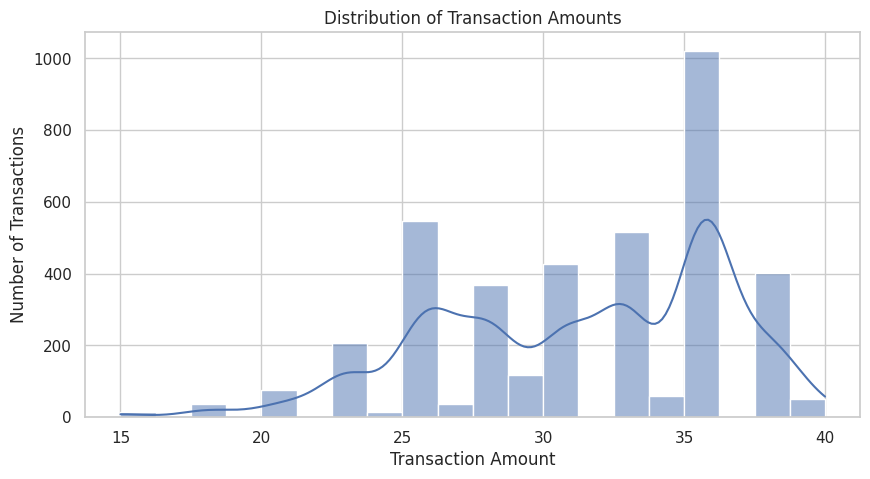

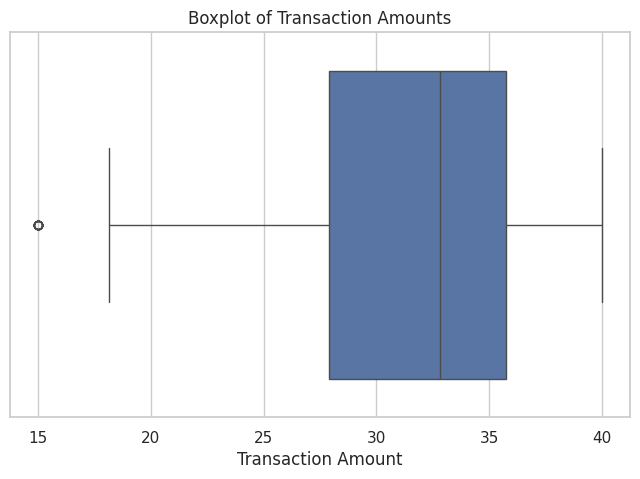

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(coffee["money"], bins=20, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=coffee["money"])
plt.title("Boxplot of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.show()

This visualization explains how customer transaction amounts are distributed across all coffee sales.

The **histogram** shows that most purchases are concentrated between **25 and 38**, with the highest number of transactions around **35 to 36**. This means many customers are spending near the higher end of the usual price range, which is a positive sign for revenue. There are fewer transactions at the lower amounts, such as **15 to 22**, suggesting that cheaper items or smaller purchases are less common.

The **boxplot** confirms that transaction amounts are fairly stable. The middle range of purchases falls between approximately **28 and 36**, while the median is around **33**, meaning half of the transactions are below this value and half are above it. The highest transaction amount reaches **40**, while there is a small low-value outlier around **15**.

From a business perspective, this shows that customers generally spend consistently per order. The coffee shop can use this insight to create bundles or upsell offers around the **30–36 price range**, since this appears to match normal customer spending behavior.


## **KPI Summary**

Core business metrics for the coffee sales dataset.


In [23]:
total_revenue = coffee["money"].sum()
total_orders = coffee["transaction_id"].nunique()
average_order_value = coffee["money"].mean()
best_selling_product = coffee["coffee_name"].value_counts().idxmax()
highest_revenue_product = coffee.groupby("coffee_name")["money"].sum().idxmax()
top_sales_month = coffee.groupby("year_month")["money"].sum().idxmax()
peak_sales_day = coffee.groupby("day_name")["money"].sum().idxmax()
peak_sales_hour = coffee.groupby("hour")["money"].sum().idxmax()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Average Order Value",
        "Best-Selling Product",
        "Highest-Revenue Product",
        "Top Sales Month",
        "Peak Sales Day",
        "Peak Sales Hour"
    ],
    "Value": [
        round(total_revenue, 2),
        total_orders,
        round(average_order_value, 2),
        best_selling_product,
        highest_revenue_product,
        top_sales_month,
        peak_sales_day,
        f"{peak_sales_hour}:00"
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Revenue,"122,271.58"
1,Total Orders,3896
2,Average Order Value,31.38
3,Best-Selling Product,Americano with Milk
4,Highest-Revenue Product,Latte
5,Top Sales Month,2025-02
6,Peak Sales Day,Tuesday
7,Peak Sales Hour,10:00


The KPI summary gives a quick business overview of the coffee shop’s sales performance. Overall, the business generated **122,271.58 in total revenue** from **3,896 customer transactions**, showing a solid volume of sales during the analysis period. On average, each customer spent around **31.38 per order**, which helps the business understand the typical spending behavior of customers.

The **best-selling product is Americano with Milk**, meaning it had the highest number of orders and is likely one of the most popular choices among customers. However, the **highest-revenue product is Latte**, meaning Latte contributed the most money to the business, possibly because of higher pricing or strong demand.

The strongest sales month was **February 2025**, which may indicate seasonal demand, successful promotions, or increased customer activity during that period. The busiest sales day was **Tuesday**, and the peak sales hour was **10:00 AM**, suggesting that many customers buy coffee in the morning.

For business decisions, this KPI summary can help guide product promotions, staffing schedules, inventory planning, and sales strategies.


## **Monthly Sales Trend**

Business question:  
**How does revenue change over time?**


In [24]:
monthly_sales = coffee.groupby("year_month").agg(
    total_revenue=("money", "sum"),
    total_orders=("transaction_id", "count"),
    average_order_value=("money", "mean")
).reset_index()

monthly_sales["mom_revenue_growth_pct"] = monthly_sales["total_revenue"].pct_change() * 100

display(monthly_sales)

,year_month,total_revenue,total_orders,average_order_value,mom_revenue_growth_pct
0,2024-03,"7,050.20",206,34.22,NaN
1,2024-04,"6,720.56",196,34.29,-4.68
2,2024-05,"9,063.42",267,33.95,34.86
3,2024-06,"7,758.76",227,34.18,-14.39
4,2024-07,"6,915.94",237,29.18,-10.86
5,2024-08,"7,613.84",272,27.99,10.09
6,2024-09,"9,988.64",344,29.04,31.19
7,2024-10,"13,891.16",426,32.61,39.07
8,2024-11,"8,590.54",259,33.17,-38.16
9,2024-12,"8,237.74",259,31.81,-4.11


The monthly sales trend shows how the coffee shop’s revenue changes from month to month. Overall, sales were not completely stable; some months performed much better than others. Revenue started at **7,050.20 in March 2024**, slightly decreased in April, then improved strongly in **May 2024** with a **34.86% increase**. Another strong growth period happened in **September and October 2024**, where revenue reached **13,891.16 in October**, supported by **426 orders**.

The biggest highlight is **February 2025**, which generated the highest revenue at **16,779.48** from **560 orders**. This was a major increase of **162.23% compared to January 2025**, making it the strongest sales month in the dataset.

However, some months declined, such as **November 2024**, **January 2025**, and **March 2025**. The March 2025 decrease should be interpreted carefully because the dataset may not cover the full month.

For stakeholders, this trend helps identify strong sales periods, weak months, and opportunities for promotions, inventory planning, and staffing decisions.


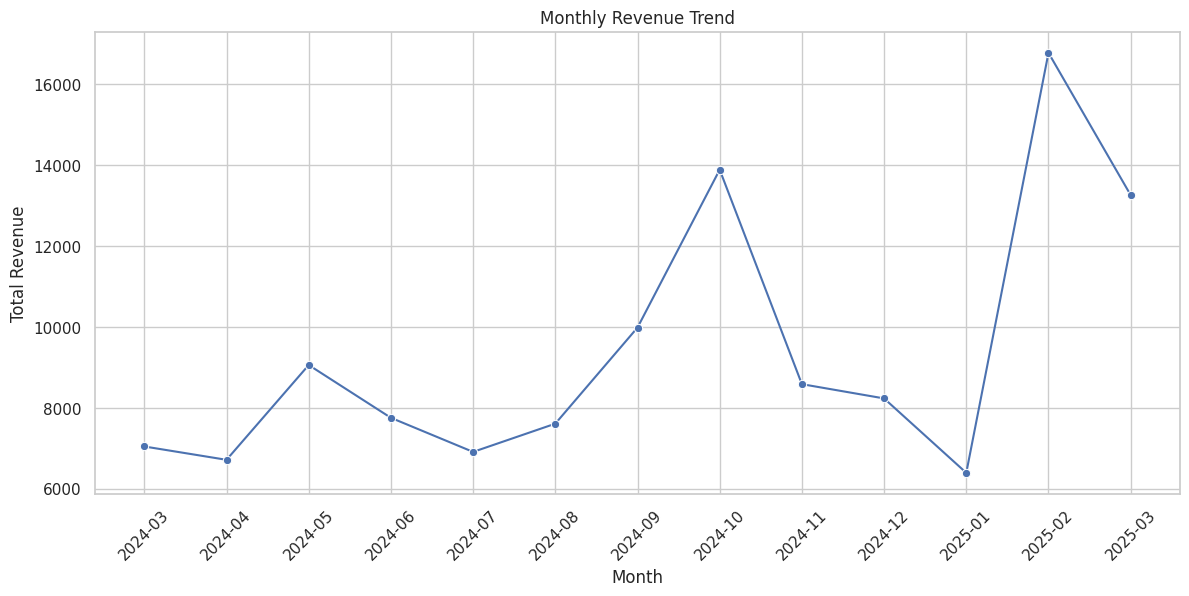

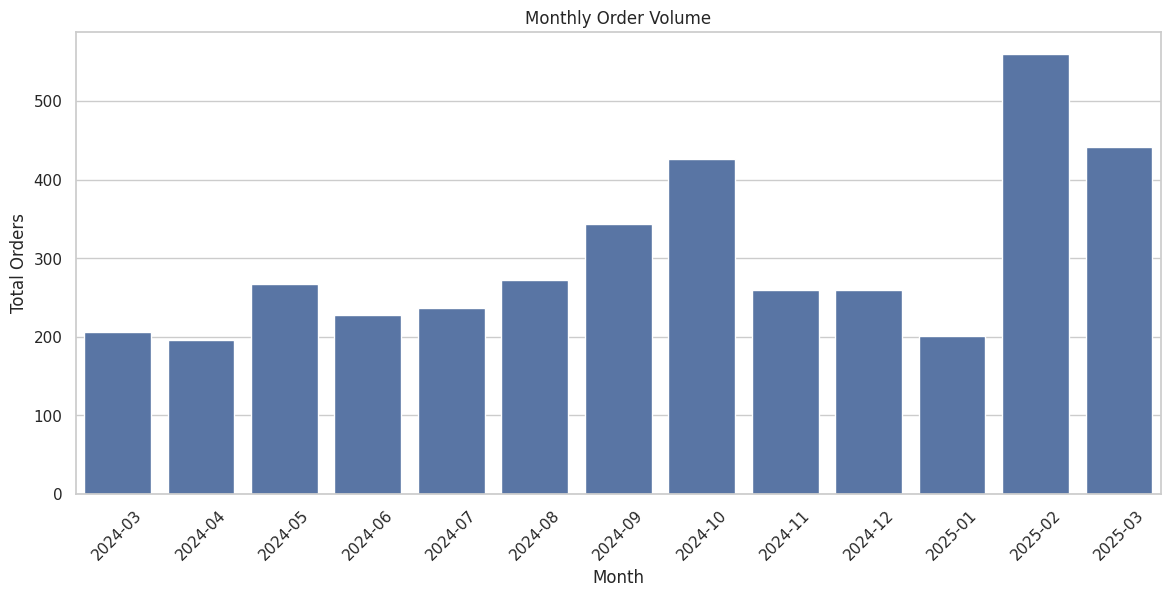

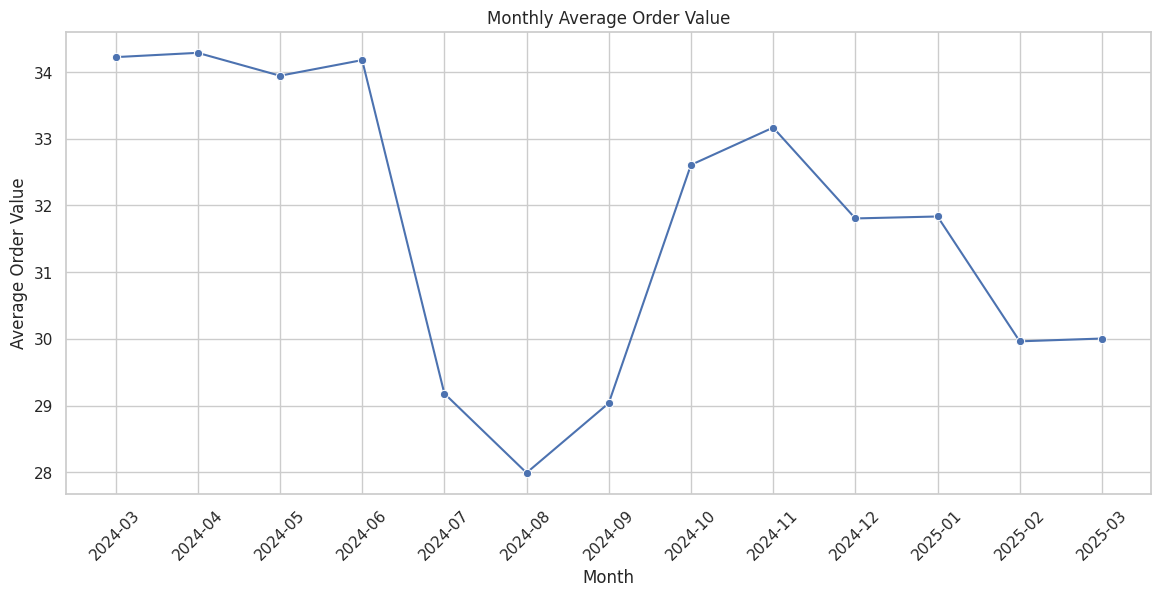

In [25]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x="year_month", y="total_revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=monthly_sales, x="year_month", y="total_orders")
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x="year_month", y="average_order_value", marker="o")
plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.show()

These charts show that the coffee shop’s sales performance changes noticeably month by month.

First, **revenue and order volume move in the same direction**, meaning higher sales are mainly driven by more customer purchases, not necessarily by customers spending much more per order. For example, **October 2024** and **February 2025** stand out as strong months because both revenue and number of orders increased significantly. **February 2025 is the best-performing month**, reaching the highest revenue and the highest number of orders.

Second, the **average order value is fairly stable but slightly declining over time**. Early months like March to June 2024 had higher average spending, around **34**, while February and March 2025 were closer to **30**. This means more customers were buying in later months, but the average amount spent per transaction was lower.

For non-technical stakeholders, the key takeaway is: **growth is being driven by transaction volume, not higher customer spending**. The business should focus on keeping customer traffic high while also encouraging upsells, bundles, or add-ons to increase the average order value. Also, **March 2025 should be reviewed carefully** because it may not represent a complete month of sales.


## **Product Performance Analysis**

Business questions:

- Which coffee products generate the most revenue?
- Which products are purchased most often?
- Which products have higher average transaction value?


In [26]:
product_performance = coffee.groupby("coffee_name").agg(
    total_revenue=("money", "sum"),
    total_orders=("transaction_id", "count"),
    average_order_value=("money", "mean")
).reset_index().sort_values("total_revenue", ascending=False)

display(product_performance)

,coffee_name,total_revenue,total_orders,average_order_value
27,Latte,"28,658.30",806,35.56
1,Americano with Milk,"26,319.12",866,30.39
2,Cappuccino,"18,514.14",517,35.81
0,Americano,"15,437.26",593,26.03
22,Hot Chocolate,"10,172.46",282,36.07
11,Cocoa,"8,678.16",243,35.71
14,Cortado,"7,534.86",292,25.80
21,Espresso,"3,187.28",152,20.97
24,Irish whiskey,525.00,21,25.00
12,Coffee with Irish whiskey,464.00,16,29.00


The **Product Performance Analysis** shows which coffee products are driving sales, customer demand, and average spending.

From the table, Latte is the top revenue-generating product, earning **28,658.30** from **806** orders. This means **Latte** is highly valuable to the business because it combines strong demand with a high average order value of **35.56**. **Americano with Milk** has the highest number of orders at **866**, making it the most frequently purchased product, but its average order value is lower at **30.39**. This means customers buy it often, but each transaction contributes slightly less revenue compared to products like Latte or Cappuccino.

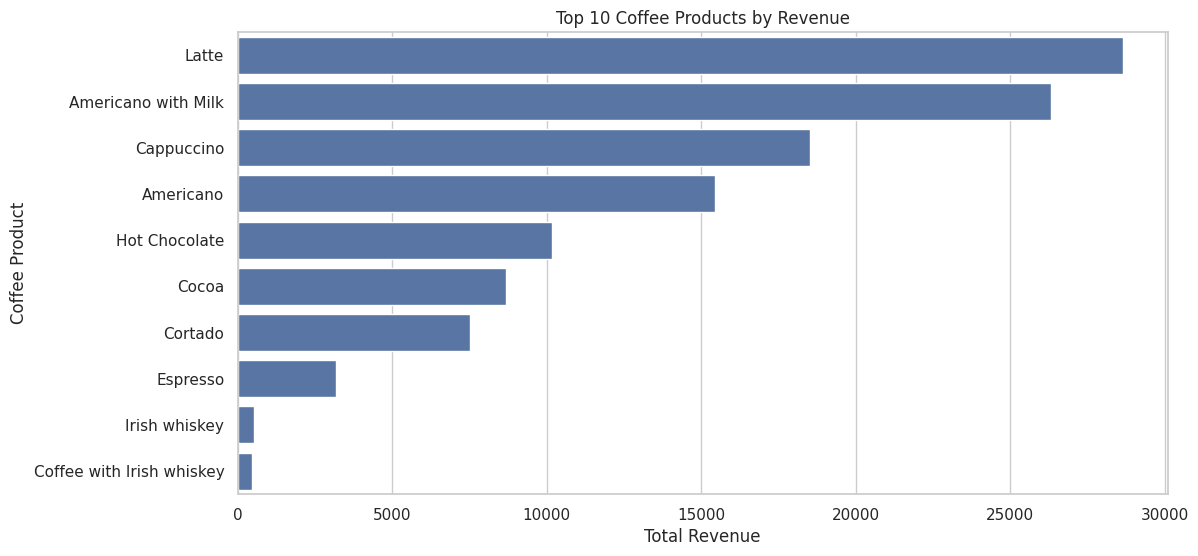

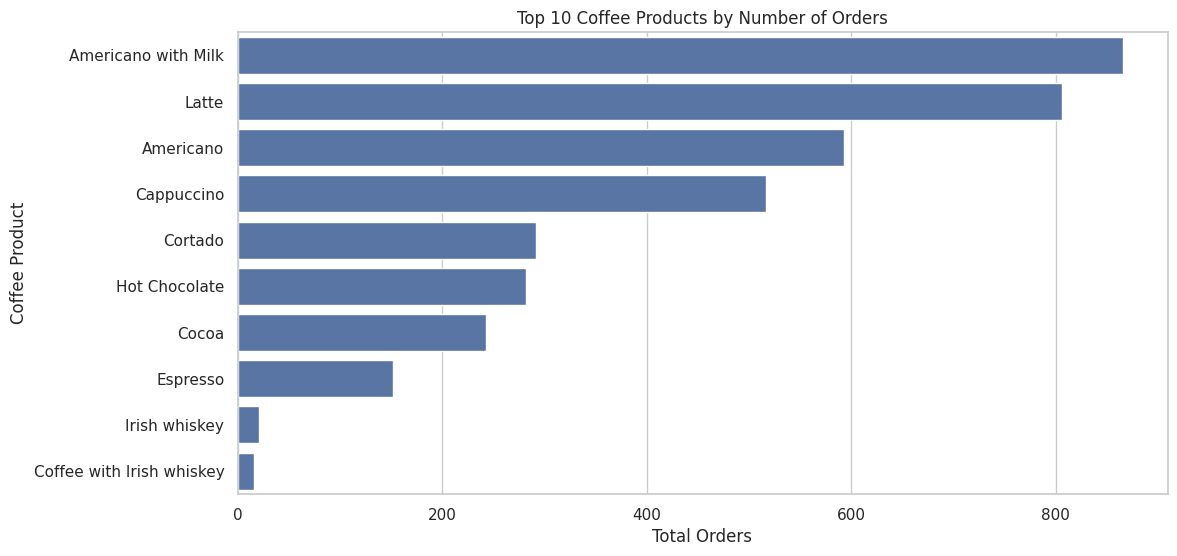

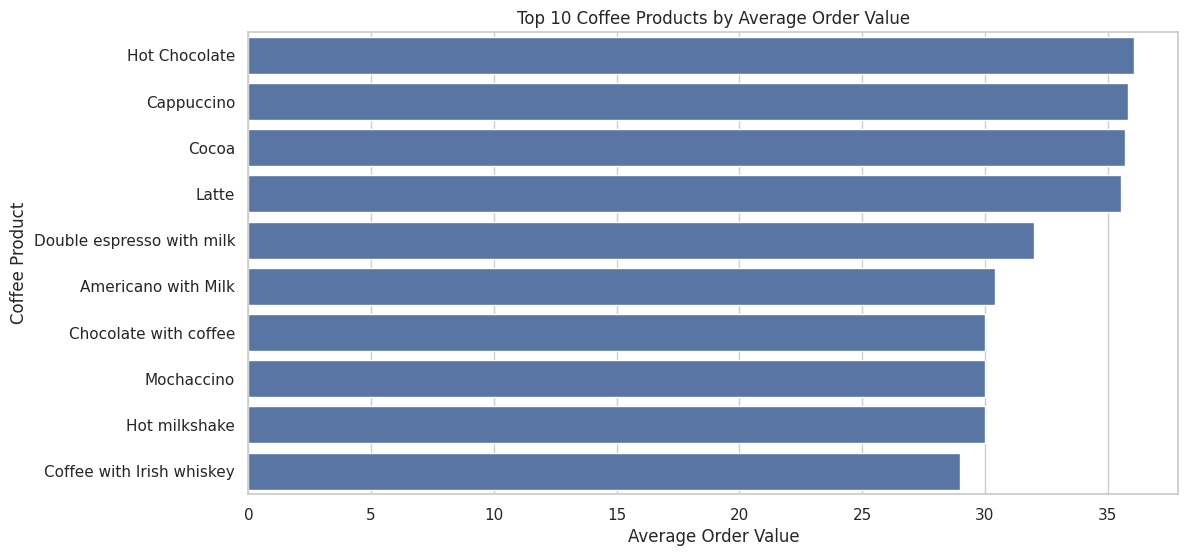

In [27]:
top_products_revenue = product_performance.sort_values("total_revenue", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_revenue, x="total_revenue", y="coffee_name")
plt.title("Top 10 Coffee Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Coffee Product")
plt.show()

top_products_orders = product_performance.sort_values("total_orders", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_orders, x="total_orders", y="coffee_name")
plt.title("Top 10 Coffee Products by Number of Orders")
plt.xlabel("Total Orders")
plt.ylabel("Coffee Product")
plt.show()

top_products_aov = product_performance.sort_values("average_order_value", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_aov, x="average_order_value", y="coffee_name")
plt.title("Top 10 Coffee Products by Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Coffee Product")
plt.show()

The charts above make this easier to understand. The **Top Products by Revenue** chart shows that Latte, Americano with Milk, Cappuccino, and Americano are the main revenue drivers. The **Top Products by Number of Orders** chart shows that Americano with Milk is the most popular product by volume. The **Average Order Value chart** shows that Hot Chocolate, Cappuccino, Cocoa, and Latte have higher spending per transaction.

For stakeholders, the key takeaway is: **Latte is the strongest business product, Americano with Milk is the strongest customer favorite, and premium products like Hot Chocolate and Cappuccino can support upselling strategies.** Lower-performing products with very few orders should be reviewed carefully before making major decisions, because some may have high average value but low customer demand.


## **Product Category Analysis**

Business question:  
**Which product categories contribute the most revenue and order volume?**


,product_category,total_revenue,total_orders,average_order_value
5,Milk-Based / Creamy,"48,070.44",1356,35.45
0,Americano-Based,"41,756.38",1459,28.62
2,Chocolate-Based,"19,493.62",548,35.57
3,Espresso-Based,"10,776.14",446,24.16
4,Irish Whiskey Flavor,"1,633.00",60,27.22
7,Tea,240.00,16,15.00
6,Other,150.00,5,30.00
1,Caramel Flavor,78.00,3,26.00
8,Vanilla Flavor,74.00,3,24.67


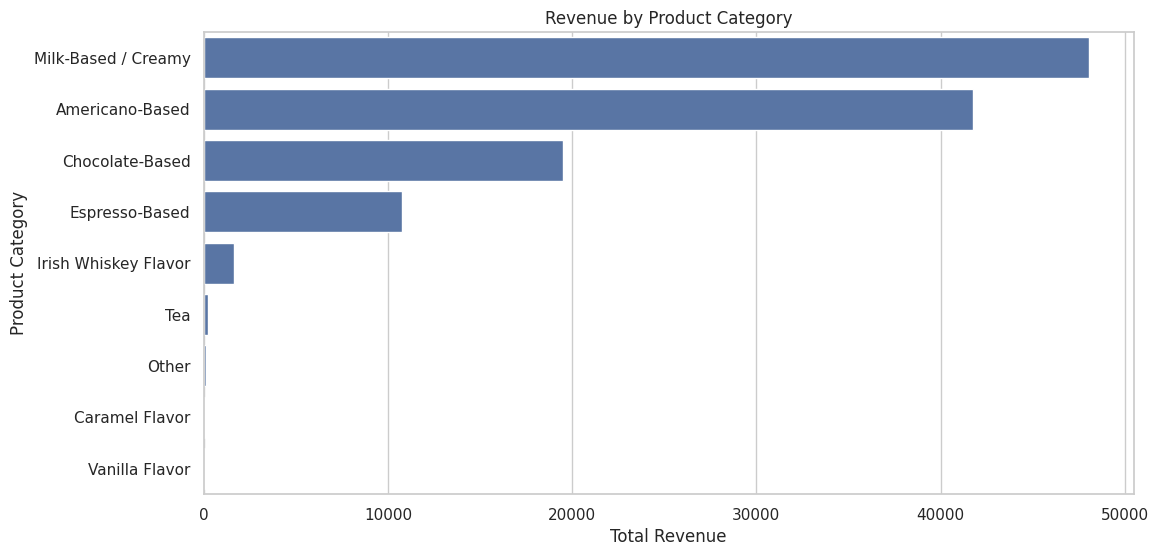

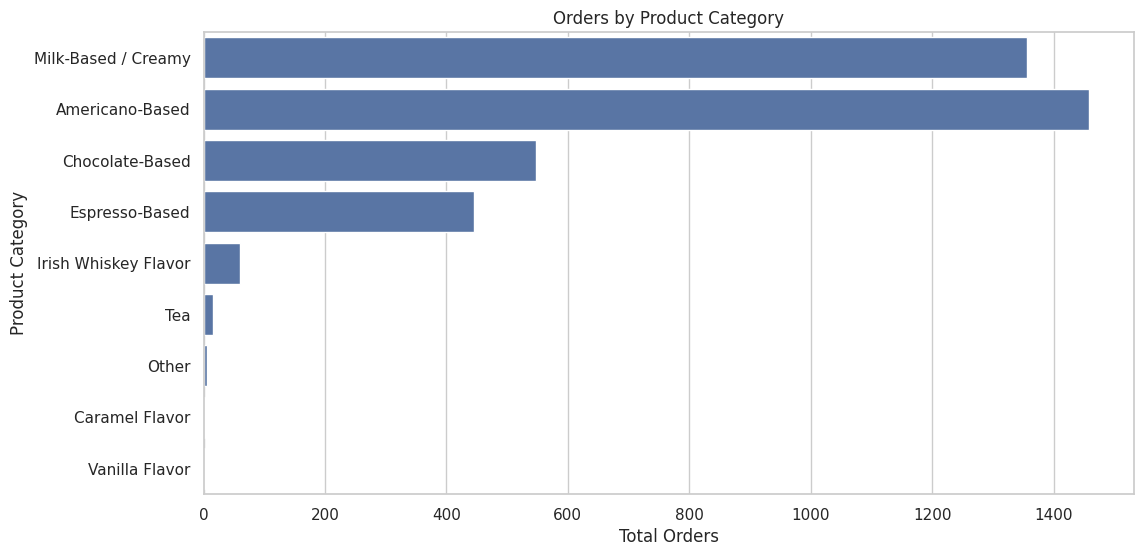

In [28]:
category_performance = coffee.groupby("product_category").agg(
    total_revenue=("money", "sum"),
    total_orders=("transaction_id", "count"),
    average_order_value=("money", "mean")
).reset_index().sort_values("total_revenue", ascending=False)

display(category_performance)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_performance, x="total_revenue", y="product_category")
plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=category_performance, x="total_orders", y="product_category")
plt.title("Orders by Product Category")
plt.xlabel("Total Orders")
plt.ylabel("Product Category")
plt.show()

The **Product Category Analysis** shows which groups of products contribute the most to overall business performance.

The strongest category is **Milk-Based / Creamy**, generating the highest revenue at **48,070.44** from **1,356 orders**. This means products such as Latte, Cappuccino, and other creamy drinks are highly valuable because customers are willing to spend more on them. This category also has a strong average order value of **35.45**, showing that it brings in higher revenue per transaction.

The **Americano-Based** category has the highest number of orders at **1,459**, but its total revenue is slightly lower at **41,756.38**. This means Americano-based drinks are the most frequently purchased, but they generate less money per order compared to milk-based drinks.

The charts clearly show that most revenue and orders come from the top three categories: **Milk-Based / Creamy, Americano-Based, and Chocolate-Based**. Smaller categories like Tea, Caramel Flavor, Vanilla Flavor, and Other contribute very little.

For stakeholders, the key takeaway is: **Milk-based drinks drive revenue, Americano-based drinks drive customer volume, and smaller categories may need review, repositioning, or promotional support.**


## **Payment Method Analysis**

Business question:  
**Do customers prefer cash or card payments?**


,cash_type,total_revenue,total_orders,average_order_value,revenue_share_pct,order_share_pct
0,card,"117,114.58",3729,31.41,95.78,95.71
1,cash,"5,157.00",167,30.88,4.22,4.29


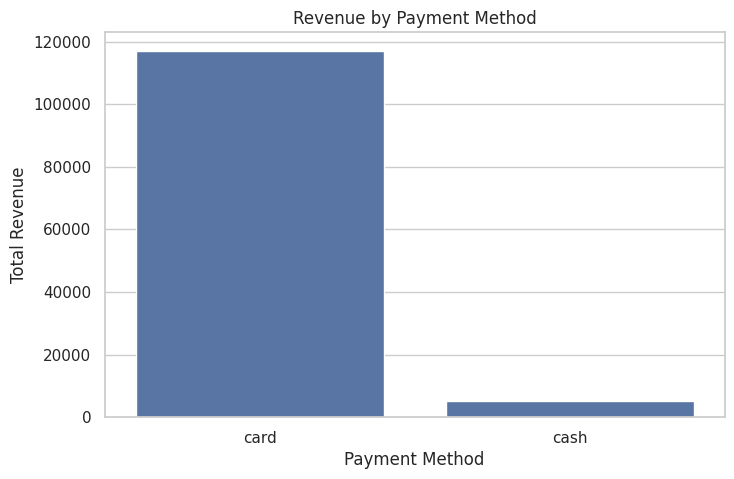

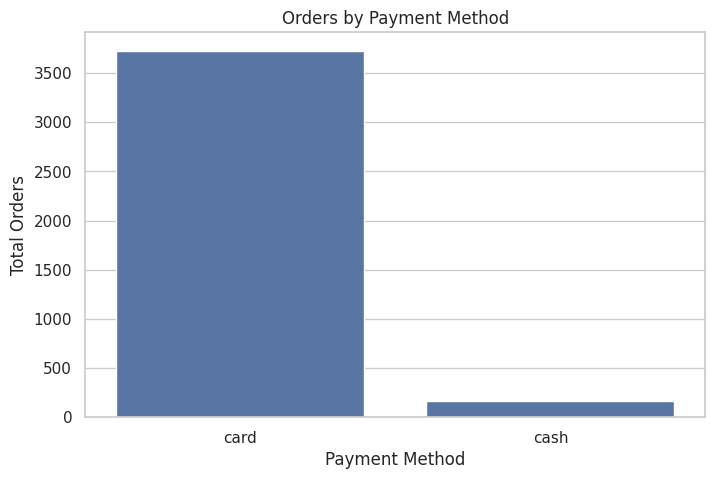

In [52]:
payment_analysis = coffee.groupby("cash_type").agg(
    total_revenue=("money", "sum"),
    total_orders=("transaction_id", "count"),
    average_order_value=("money", "mean")
).reset_index()

payment_analysis["revenue_share_pct"] = payment_analysis["total_revenue"] / payment_analysis["total_revenue"].sum() * 100
payment_analysis["order_share_pct"] = payment_analysis["total_orders"] / payment_analysis["total_orders"].sum() * 100

display(payment_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(data=payment_analysis, x="cash_type", y="total_revenue")
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=payment_analysis, x="cash_type", y="total_orders")
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Orders")
plt.show()

The analysis shows that customers strongly prefer **card payments** over cash. Out of **3,896 total transactions**, **3,729 orders were paid by card**, representing about **95.71% of all orders**. In terms of revenue, card payments generated **117,114.58**, which is around **95.78% of total sales**. Cash payments were much lower, with only **167 orders**, contributing **5,157.00** or about **4.22% of total revenue**.

A key insight is that the **average order value is almost the same** for both payment methods. Card transactions average **31.41**, while cash transactions average **30.88**. This means customers who pay by card are not necessarily spending much more per order; the main difference is simply that far more customers are using card.

From a business perspective, this suggests that card payment is the dominant customer behavior. The coffee shop should make sure card payment systems are always reliable, fast, and available. Since card payments dominate, the business can also use card-based customer identifiers to support loyalty programs, repeat customer tracking, and personalized promotions. Cash should still be accepted, but operational focus should prioritize smooth digital/card payment experiences.


## **Day-of-Week Sales Analysis**

Business question:  
**Which days generate the strongest sales?**


,day_number,day_name,total_revenue,total_orders,average_order_value
0,0,Monday,"18,714.10",591,31.67
1,1,Tuesday,"19,148.38",604,31.70
2,2,Wednesday,"17,157.46",552,31.08
3,3,Thursday,"17,025.40",540,31.53
4,4,Friday,"18,357.66",586,31.33
5,5,Saturday,"16,422.52",531,30.93
6,6,Sunday,"15,446.06",492,31.39


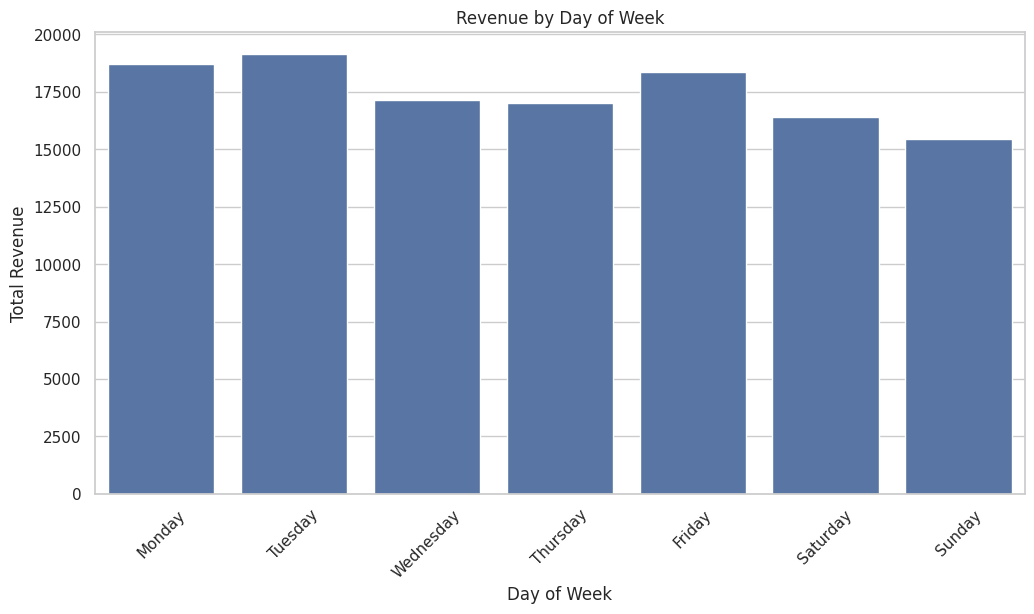

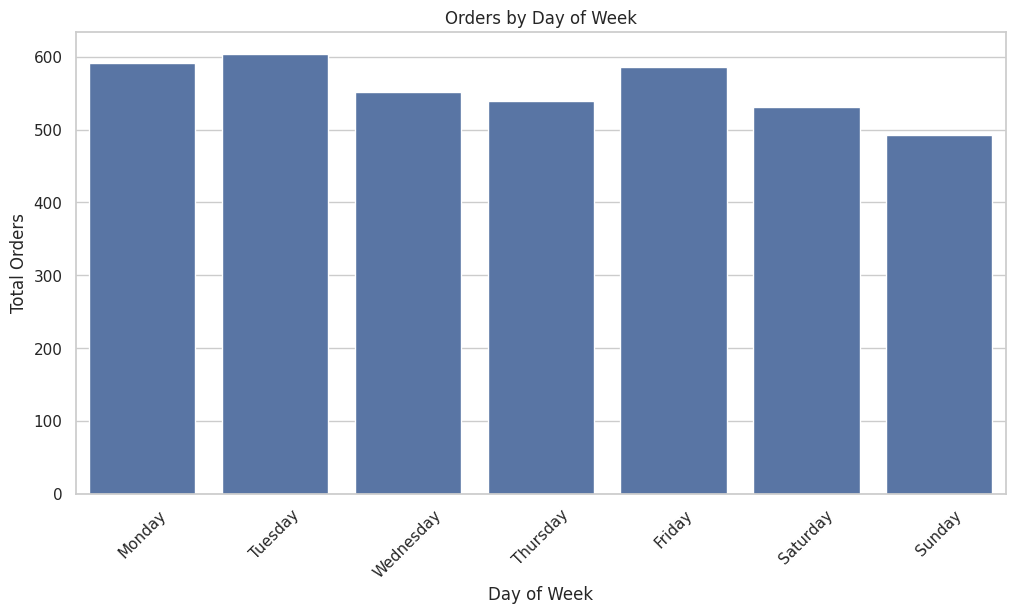

In [31]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_sales = coffee.groupby(["day_number", "day_name"]).agg(
    total_revenue=("money", "sum"),
    total_orders=("transaction_id", "count"),
    average_order_value=("money", "mean")
).reset_index().sort_values("day_number")

display(daily_sales)

plt.figure(figsize=(12, 6))
sns.barplot(data=daily_sales, x="day_name", y="total_revenue", order=day_order)
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=daily_sales, x="day_name", y="total_orders", order=day_order)
plt.title("Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

The **Day-of-Week Sales Analysis** shows that sales are strongest during the weekdays, especially on **Tuesday**, which generated the highest revenue at **19,148.38** with **604 orders**. This makes Tuesday the best-performing day overall. **Monday** and **Friday** also performed strongly, with revenues of **18,714.10** and **18,357.66**, showing that the business gets consistent customer demand during the workweek.

The weakest sales day is **Sunday**, with **15,446.06 revenue** and **492 orders**. Saturday is also lower compared to weekdays, which suggests that this coffee shop may be more dependent on weekday customer routines, such as work, school, commuting, or morning coffee habits.

One important insight is that the **average order value is very similar across all days**, ranging around **30.93 to 31.70**. This means the difference in revenue is mainly caused by the **number of customers/orders**, not because customers spend much more on certain days.

For business decisions, the coffee shop should prepare more staff and inventory on **Tuesday, Monday, and Friday**. For slower days like **Saturday and Sunday**, the business can consider weekend promotions, bundle offers, or loyalty rewards to increase customer traffic.


## **Hourly Sales Analysis**

Business question:  
**What time of day has the highest customer demand?**


,hour,total_revenue,total_orders,average_order_value
0,6,149.40,5,29.88
1,7,"3,161.02",99,31.93
2,8,"7,329.88",246,29.80
3,9,"7,672.28",257,29.85
4,10,"11,332.52",362,31.31
5,11,"9,411.10",316,29.78
6,12,"8,190.62",271,30.22
7,13,"7,448.76",241,30.91
8,14,"7,705.80",245,31.45
9,15,"8,380.02",267,31.39


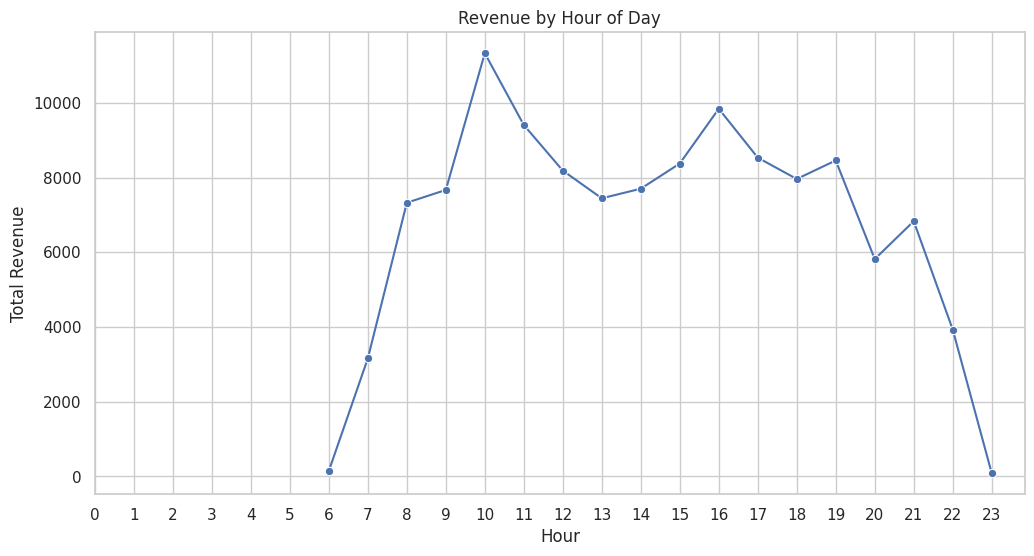

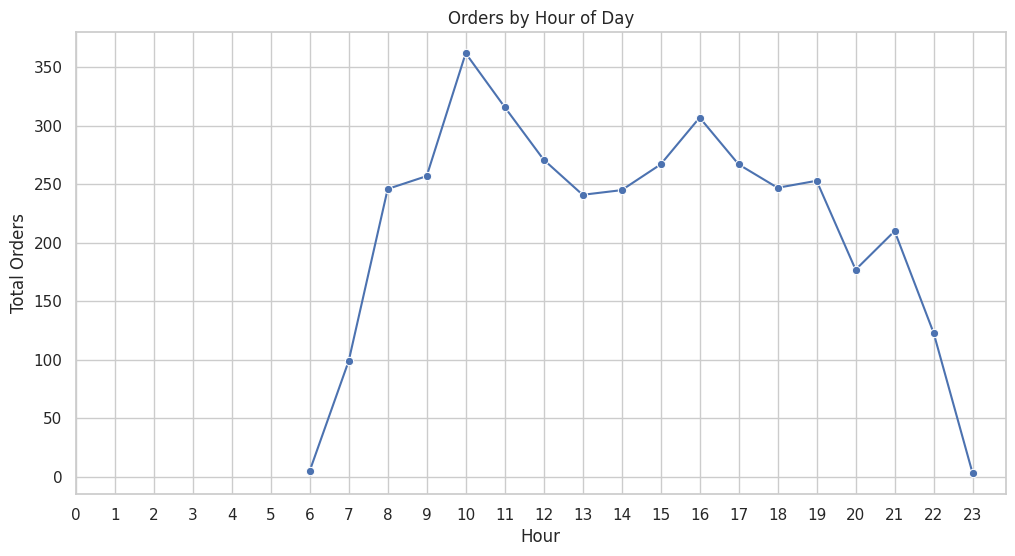

In [32]:
hourly_sales = coffee.groupby("hour").agg(
    total_revenue=("money", "sum"),
    total_orders=("transaction_id", "count"),
    average_order_value=("money", "mean")
).reset_index()

display(hourly_sales)

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_sales, x="hour", y="total_revenue", marker="o")
plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total Revenue")
plt.xticks(range(0, 24))
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_sales, x="hour", y="total_orders", marker="o")
plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total Orders")
plt.xticks(range(0, 24))
plt.show()

The **Hourly Sales Analysis** shows that customer demand is strongest during the **morning period**, especially at **10:00 AM**. This hour generated the highest revenue at **11,332.52** and the highest number of orders with **362 transactions**, making it the busiest and most profitable time of the day.

Sales start very low at **6:00 AM**, then quickly increase from **7:00 AM to 10:00 AM**, which suggests that many customers buy coffee during their morning routine, commute, work break, or start of the day. After 10:00 AM, sales remain strong until around **12:00 PM**, then become more stable in the afternoon.

Another important peak happens around **4:00 PM**, with **307 orders** and **9,846.60 revenue**. This may represent an afternoon coffee break or customers buying coffee later in the day for an energy boost.

The **average order value is fairly consistent**, mostly around **29 to 33**, meaning revenue changes are mainly caused by the number of customers, not big changes in spending per order.

**Business Insight:** The coffee shop should prioritize staffing, inventory, and product availability before and during **10:00 AM**, since this is the highest-demand hour. For slower hours, especially early morning and late evening, the business can test promotions, discounts, or bundle offers to increase traffic.


## **Heatmap: Sales by Day and Hour**

Business question:  
**What day-hour combinations are the busiest?**


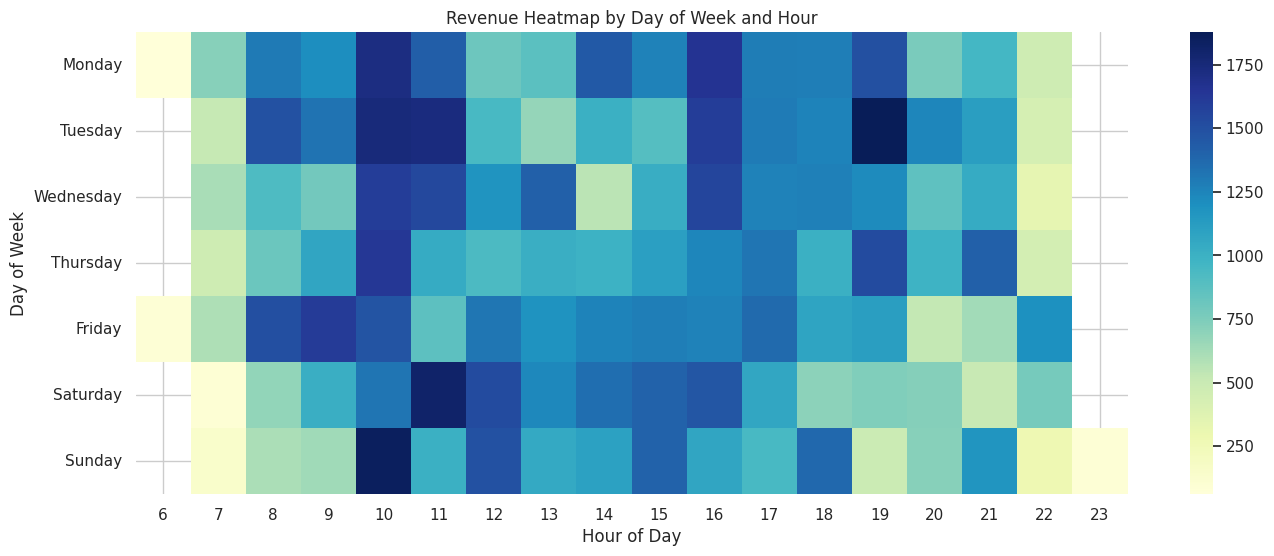

In [33]:
heatmap_data = coffee.pivot_table(
    index="day_name",
    columns="hour",
    values="money",
    aggfunc="sum"
).reindex(day_order)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, fmt=".0f")
plt.title("Revenue Heatmap by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

The **Sales by Day and Hour heatmap** helps identify the exact time windows when the coffee shop earns the most revenue. In this chart, the **darker areas represent stronger sales**, while lighter areas represent weaker sales periods.

The busiest day-hour combinations appear to be **Tuesday around 7 PM**, **Sunday around 10 AM**, **Saturday around 11 AM**, and several strong morning periods such as **Monday to Friday around 8 AM to 11 AM**. This shows that customer demand is not only concentrated in the morning but also has selected afternoon and evening peaks.

A clear pattern is that **morning coffee demand is consistently strong**, especially around **10 AM to 11 AM**. This likely reflects customer routines such as work breaks, commuting, or mid-morning purchases. There are also strong sales pockets around **4 PM to 7 PM**, which may represent afternoon coffee breaks or after-work purchases.

From a business perspective, the coffee shop should ensure enough staff, ingredients, and product availability during these peak time blocks. Slower periods, especially very early morning and late evening, can be targeted with promotions, bundle offers, or loyalty incentives to increase customer traffic.


## **Customer Behavior Analysis**

The `card` column acts as an anonymized customer identifier.

Important note:

- Missing card values should not be deleted from sales analysis.
- Customer-level analysis should only use rows where `card` is available.


Total unique card customers: 1316
Repeat customers: 545
Repeat customer rate: 41.41 %


,card,purchase_count,total_spent,average_spend,first_purchase,last_purchase,customer_lifespan_days
11,ANON-0000-0000-0012,129,"3,785.92",29.35,2024-03-02 11:59:45.484,2025-01-20 08:29:47.959,323
140,ANON-0000-0000-0141,108,"2,749.78",25.46,2024-04-29 11:26:31.871,2025-02-01 13:15:29.243,278
1162,ANON-0000-0000-1163,77,"2,278.22",29.59,2025-02-03 17:11:07.189,2025-03-21 15:29:32.330,45
275,ANON-0000-0000-0276,69,"2,119.54",30.72,2024-06-09 12:11:23.640,2025-01-30 10:12:33.868,234
8,ANON-0000-0000-0009,67,"2,343.98",34.98,2024-03-01 19:29:17.391,2024-08-10 16:06:12.085,161
506,ANON-0000-0000-0507,51,"1,797.30",35.24,2024-08-14 21:41:33.021,2025-03-21 18:52:12.666,218
39,ANON-0000-0000-0040,50,"1,519.48",30.39,2024-03-09 12:13:03.521,2024-12-19 19:10:40.561,285
96,ANON-0000-0000-0097,47,"1,477.86",31.44,2024-04-05 12:14:27.975,2024-12-25 20:02:40.331,264
1109,ANON-0000-0000-1110,33,886.08,26.85,2025-01-17 14:20:53.972,2025-03-21 15:28:19.564,63
1169,ANON-0000-0000-1170,32,850.32,26.57,2025-02-04 14:15:14.010,2025-03-21 18:59:24.271,45


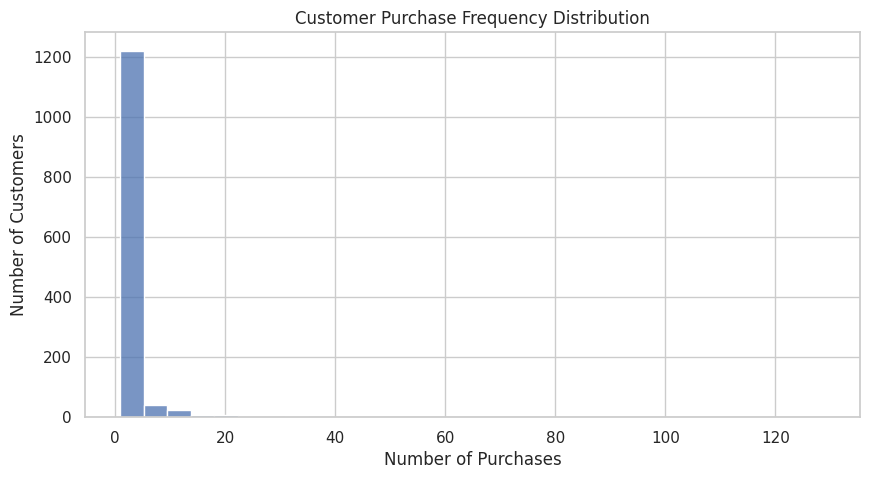

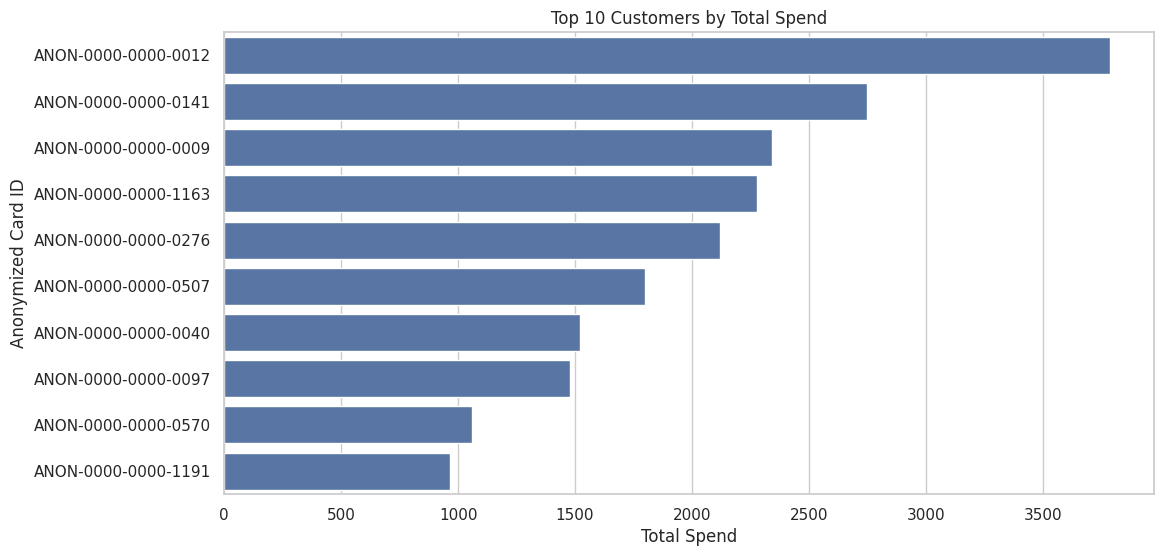

In [53]:
customer_sales = coffee[coffee["card"].notna()].copy()

customer_summary = customer_sales.groupby("card").agg(
    purchase_count=("transaction_id", "count"),
    total_spent=("money", "sum"),
    average_spend=("money", "mean"),
    first_purchase=("datetime", "min"),
    last_purchase=("datetime", "max")
).reset_index()

customer_summary["customer_lifespan_days"] = (
    customer_summary["last_purchase"] - customer_summary["first_purchase"]
).dt.days

repeat_customers = customer_summary[customer_summary["purchase_count"] > 1]

print("Total unique card customers:", customer_summary["card"].nunique())
print("Repeat customers:", len(repeat_customers))
print("Repeat customer rate:", round(len(repeat_customers) / len(customer_summary) * 100, 2), "%")

display(customer_summary.sort_values("purchase_count", ascending=False).head(10))

plt.figure(figsize=(10, 5))
sns.histplot(customer_summary["purchase_count"], bins=30)
plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

top_customers = customer_summary.sort_values("total_spent", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_customers, x="total_spent", y="card")
plt.title("Top 10 Customers by Total Spend")
plt.xlabel("Total Spend")
plt.ylabel("Anonymized Card ID")
plt.show()

The **Customer Behavior Analysis** shows that the coffee shop has a strong opportunity to build customer loyalty. Based on the available card data, there are **1,316 unique card customers**, and **545 of them are repeat customers**. This gives a **repeat customer rate of 41.41%**, which means around 4 out of every 10 identified card customers returned to buy again. For a coffee business, this is a positive sign because coffee purchases are often habit-based and can lead to regular customer routines.

The customer table shows that some customers are highly valuable. For example, the top customer made **129 purchases** and spent **3,785.92**, while another customer made **108 purchases** and spent **2,749.78**. These customers are important because they contribute consistent revenue over time.

However, the purchase frequency chart shows that most customers only purchased once or a few times. This means the business has many occasional customers, but only a smaller group of highly loyal customers.

The main business insight is that the coffee shop should focus on **customer retention**. A loyalty program, rewards for repeat purchases, personalized offers, or “buy X coffees, get 1 free” campaigns could encourage one-time buyers to return more often. The top-spending customers can also be treated as VIP customers through exclusive discounts or early access to promotions.

One important note: this analysis should only be used for customers with available card IDs. Cash customers or transactions without card information should still be included in overall sales analysis, but not in customer-level behavior tracking.


## **Correlation Check**

Since this dataset is mostly transactional and categorical, correlation analysis is limited.  
However, we can check relationships between numeric columns such as transaction amount, hour, month, and day number.


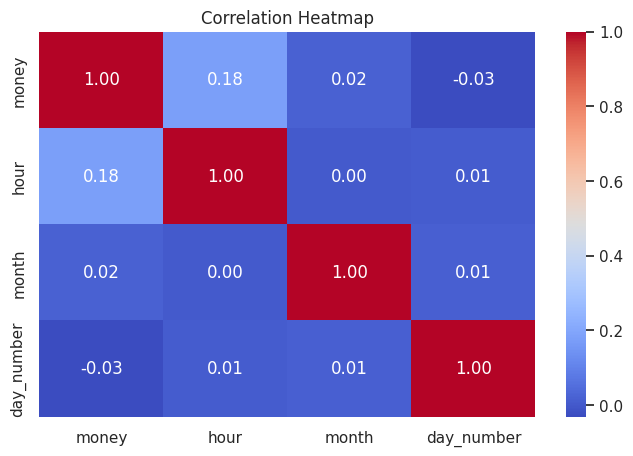

In [36]:
numeric_cols = ["money", "hour", "month", "day_number"]

plt.figure(figsize=(8, 5))
sns.heatmap(coffee[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The **Correlation Check** shows whether numeric variables move strongly together, such as transaction amount, hour, month, and day of the week.

The main finding is that there is **no strong correlation** between transaction amount and the time-related columns. The relationship between **transaction amount and hour** is only **0.18**, which is a very weak positive relationship. This means customers may spend slightly more at certain hours, but the pattern is not strong enough to say that time of day directly affects how much a customer spends.

The relationship between **transaction amount and month** is almost zero at **0.02**, and the relationship between **transaction amount and day number** is also very weak at **-0.03**. This means customer spending per order is fairly consistent across months and days.

For stakeholders, the key insight is: **sales changes are not mainly caused by customers spending more at certain times. Instead, revenue changes are more likely driven by order volume and product choices.** So, the business should focus more on increasing customer traffic, promoting high-performing products, and improving peak-hour operations rather than relying on specific days or months to increase average spend.


## **Business Insights Summary**

Run the cell below to automatically generate a simple business summary based on the dataset.


In [37]:
top_revenue_product = product_performance.sort_values("total_revenue", ascending=False).iloc[0]
top_order_product = product_performance.sort_values("total_orders", ascending=False).iloc[0]
top_month = monthly_sales.sort_values("total_revenue", ascending=False).iloc[0]
top_day = daily_sales.sort_values("total_revenue", ascending=False).iloc[0]
top_hour = hourly_sales.sort_values("total_revenue", ascending=False).iloc[0]
top_payment = payment_analysis.sort_values("total_orders", ascending=False).iloc[0]

print("BUSINESS INSIGHTS SUMMARY")
print("-" * 60)
print(f"Total revenue generated: {total_revenue:,.2f}")
print(f"Total orders recorded: {total_orders:,}")
print(f"Average order value: {average_order_value:,.2f}")
print(f"Highest-revenue product: {top_revenue_product['coffee_name']} ({top_revenue_product['total_revenue']:,.2f})")
print(f"Most ordered product: {top_order_product['coffee_name']} ({top_order_product['total_orders']:,} orders)")
print(f"Top sales month: {top_month['year_month']} ({top_month['total_revenue']:,.2f})")
print(f"Peak sales day: {top_day['day_name']} ({top_day['total_revenue']:,.2f})")
print(f"Peak sales hour: {int(top_hour['hour'])}:00 ({top_hour['total_revenue']:,.2f})")
print(f"Most used payment method: {top_payment['cash_type']} ({top_payment['total_orders']:,} orders)")
print(f"Repeat customer rate based on card IDs: {len(repeat_customers) / len(customer_summary) * 100:.2f}%")

BUSINESS INSIGHTS SUMMARY
------------------------------------------------------------
Total revenue generated: 122,271.58
Total orders recorded: 3,896
Average order value: 31.38
Highest-revenue product: Latte (28,658.30)
Most ordered product: Americano with Milk (866 orders)
Top sales month: 2025-02 (16,779.48)
Peak sales day: Tuesday (19,148.38)
Peak sales hour: 10:00 (11,332.52)
Most used payment method: card (3,729 orders)
Repeat customer rate based on card IDs: 41.41%


The **Business Insights Summary** gives a clear overview of how the coffee business performed during the analysis period. Overall, the business generated **122,271.58 in total revenue** from **3,896 orders**, which shows that the shop had a strong number of completed transactions. The **average order value is 31.38**, meaning that, on average, each customer spent around 31 per purchase. This is useful because it gives the business a baseline for understanding typical customer spending.

One important product insight is that **Latte is the highest-revenue product**, generating **28,658.30**. This means Latte is one of the most financially valuable products for the business and should be prioritized in promotions, product placement, and inventory planning. On the other hand, **Americano with Milk is the most ordered product**, with **866 orders**. This shows that it is the most popular item among customers, even though it does not generate the highest total revenue. This difference is important because it tells stakeholders that popularity and revenue contribution are not always the same.

The strongest sales month was **February 2025**, with **16,779.48 in revenue**. This month should be studied further to understand what caused the increase, such as higher customer demand, seasonal behavior, or possible promotions. The **peak sales day is Tuesday**, generating **19,148.38**, while the **peak sales hour is 10:00 AM**, generating **11,332.52**. These findings suggest that customer demand is strongest during weekday routines and morning coffee hours.

The most used payment method is **card**, with **3,729 orders**, showing that customers strongly prefer cashless transactions. The business should make sure card payment systems are reliable and convenient.

Lastly, the **repeat customer rate is 41.41% based on card IDs**, meaning many identified customers returned to purchase again. This is a positive sign for customer loyalty. The business can improve this further through loyalty rewards, personalized offers, and promotions targeted at repeat buyers. Overall, the business should focus on high-performing products, peak-hour readiness, and customer retention strategies.


## **Business Recommendations**

Based on the Coffee Sales Analysis, these are the main **business recommendations** I would present as a Data/Business Analyst:

### **1. Prioritize high-revenue products in promotions**

The business should focus marketing and promotional efforts on **Latte**, since it generated the highest revenue at **28,658.30**. This means Latte is one of the most valuable products for the business. It can be featured in bundle offers, loyalty rewards, display menus, and upselling campaigns.

For example, the shop can promote:

**“Latte + pastry combo”**
**“Upgrade to large Latte”**
**“Buy 5 Lattes, get 1 free”**

This can help increase revenue from a product that already performs well.

### **2. Protect inventory for best-selling products**

**Americano with Milk** is the most ordered product with **866 orders**, meaning it has the strongest customer demand. The business should make sure ingredients for this product are always available, especially during peak hours and peak days.

Running out of a high-demand product could result in missed sales and poor customer experience.

### **3. Increase staffing and preparation during peak sales periods**

The analysis shows that the peak sales day is **Tuesday**, and the peak sales hour is **10:00 AM**. This means the business should prepare more staff, supplies, and ingredients before this time.

A good operational strategy would be to schedule more baristas or prepare ingredients earlier during morning hours, especially from **8:00 AM to 11:00 AM**.

### **4. Create promotions for weaker days and hours**

Sales are weaker during weekends, especially **Sunday**, compared to weekdays. The business can introduce weekend-focused promotions to increase customer traffic.

Examples include:

**Weekend coffee bundles**
**Sunday discount offers**
**Buy-one-get-one promotions during slow hours**
**Limited-time seasonal drinks**

This can help balance sales across the week instead of relying mostly on weekday customers.

### **5. Build a loyalty program for repeat customers**

The repeat customer rate is **41.41% based on card IDs**, which means many customers are already returning. This is a strong opportunity to increase customer retention.

The business can create a loyalty program such as:

**Buy 10 coffees, get 1 free**
**Points per purchase**
**Birthday rewards**
**Exclusive offers for frequent buyers**

This can encourage one-time customers to become repeat customers.

### **6. Improve cashless payment experience**

Card payments dominate the business, with **3,729 card orders**. Since most customers prefer card payments, the shop should make sure card payment systems are fast, reliable, and always available.

The business can also use card-based customer behavior, while keeping customer privacy protected, to understand repeat purchases and customer loyalty trends.

### **7. Review low-performing products**

Some products have very low order volume and revenue. These products should be reviewed to decide whether they should be improved, bundled, promoted, or removed from the menu.

However, the business should not remove them immediately. Low sales may be caused by poor visibility, limited awareness, or lack of promotion. Testing small campaigns first would be better.

### **8. Use dashboards for regular decision-making**

The business should track key metrics monthly, such as total revenue, total orders, average order value, top products, peak hours, and repeat customer rate. This will help management make decisions based on actual data instead of assumptions.

Overall, the best strategy is to **promote high-performing products, prepare for peak demand, improve customer retention, and use slow periods as opportunities for targeted promotions**.


## **Export Cleaned Data and Summary Tables**

These exported files can be used for SQL Server, Power BI, Tableau, or Excel.


In [38]:
coffee.to_csv("coffee_sales_cleaned.csv", index=False)
monthly_sales.to_csv("monthly_sales_summary.csv", index=False)
product_performance.to_csv("product_performance_summary.csv", index=False)
category_performance.to_csv("category_performance_summary.csv", index=False)
payment_analysis.to_csv("payment_analysis_summary.csv", index=False)
daily_sales.to_csv("daily_sales_summary.csv", index=False)
hourly_sales.to_csv("hourly_sales_summary.csv", index=False)
customer_summary.to_csv("customer_summary.csv", index=False)

print("Export completed successfully.")

Export completed successfully.


# ✅ **EDA Conclusion**

This EDA transformed raw coffee transaction data into business-ready insights.

The analysis identified:

- Total revenue and order performance
- Best-selling and highest-revenue products
- Monthly sales patterns
- Peak sales days and hours
- Payment method preferences
- Repeat customer behavior
- Product category performance
- Practical business recommendations

This notebook can be used as the analytical foundation for a Power BI or Tableau dashboard and as a strong portfolio project for Data Analyst, Business Analyst, and BI Analyst applications.
